In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import warnings
from sklearn.decomposition import TruncatedSVD
import re
plt.style.use('default')

In [2]:
def natural_key(string_):
    return [int(s) if s.isdigit() else s.lower() for s in re.split('([0-9]+)', string_)]

In [3]:
dataset_path = "./dataset/" 
orig_dir = os.path.join(dataset_path, 'originalData')
mask_dir = os.path.join(dataset_path, 'annotatedData')

orig_files = sorted([f for f in os.listdir(orig_dir) if not f.startswith('.')], key=natural_key)
mask_files = sorted([f for f in os.listdir(mask_dir) if not f.startswith('.')], key=natural_key)

In [4]:
thermal_sequence_list = []
mask_sequence_list = []

for i, filename in enumerate(orig_files):
    orig_path = os.path.join(orig_dir, filename)
    mask_path = os.path.join(mask_dir, filename)
    orig_img = cv2.imread(orig_path, cv2.IMREAD_GRAYSCALE)
    mask_img = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    thermal_sequence_list.append(orig_img)
    _, binary_mask = cv2.threshold(mask_img, 1, 255, cv2.THRESH_BINARY)
    mask_sequence_list.append(binary_mask / 255.0) # Normalize to 0/1
thermal_volume = np.stack(thermal_sequence_list, axis=0).astype(np.float32)
mask_volume = np.stack(mask_sequence_list, axis=0).astype(np.float32)

In [5]:
# Principal Component Thermography
def compute_pct(thermal_seq, n_components=5):
    T, H, W = thermal_seq.shape
    mean_profile = np.mean(thermal_seq, axis=(1, 2), keepdims=True)
    norm_sequence = thermal_seq - mean_profile
    flattened_data = norm_sequence.reshape(T, -1)
    
    svd = TruncatedSVD(n_components=n_components, random_state=42)
    eof_spatial = svd.fit_transform(flattened_data.T) 
    return eof_spatial.T.reshape(n_components, H, W)

In [6]:
# Pulsed Phase Thermography (1D FFT)
def compute_ppt_phase(thermal_seq):
    fft_result = np.fft.fft(thermal_seq, axis=0)
    phase_images = np.angle(fft_result)
    half_T = phase_images.shape[0] // 2
    return phase_images[:half_T]

In [7]:
# Thermographic Signal Reconstruction
def compute_tsr_derivatives(thermal_seq, poly_degree=5):
    T, H, W = thermal_seq.shape
    time_steps = np.arange(1, T + 1)    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        log_t = np.log(time_steps)
        log_T_data = np.nan_to_num(np.log(thermal_seq), neginf=0)
    
    log_T_flat = log_T_data.reshape(T, -1).T
    coeffs = np.polyfit(log_t, log_T_flat.T, deg=poly_degree)
    
    first_deriv_flat = np.zeros_like(log_T_flat)
    second_deriv_flat = np.zeros_like(log_T_flat)
    
    for i in range(H * W):
        p = np.poly1d(coeffs[:, i])
        first_deriv_flat[i, :] = p.deriv(1)(log_t)
        second_deriv_flat[i, :] = p.deriv(2)(log_t)
        
    return first_deriv_flat.T.reshape(T, H, W), second_deriv_flat.T.reshape(T, H, W)

In [8]:
pct_components = compute_pct(thermal_volume)
ppt_phase = compute_ppt_phase(thermal_volume)
tsr_d1, tsr_d2 = compute_tsr_derivatives(thermal_volume)

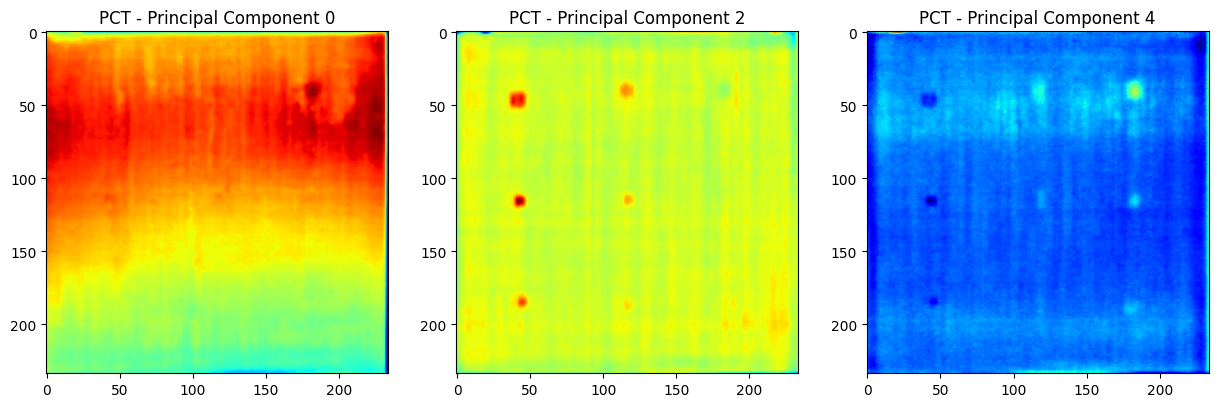

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(pct_components[0], cmap='jet')
axes[0].set_title("PCT - Principal Component 0")
axes[1].imshow(pct_components[2], cmap='jet')
axes[1].set_title("PCT - Principal Component 2")
axes[2].imshow(pct_components[4], cmap='jet')
axes[2].set_title("PCT - Principal Component 4")
plt.show()

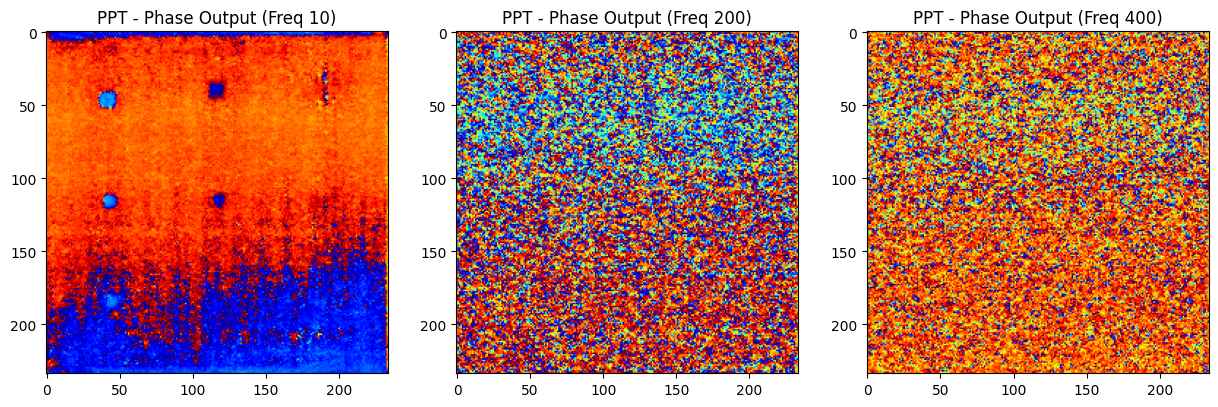

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(ppt_phase[10], cmap='jet')
axes[0].set_title("PPT - Phase Output (Freq 10)")
axes[1].imshow(ppt_phase[200], cmap='jet')
axes[1].set_title("PPT - Phase Output (Freq 200)")
axes[2].imshow(ppt_phase[400], cmap='jet')
axes[2].set_title("PPT - Phase Output (Freq 400)")
plt.show()

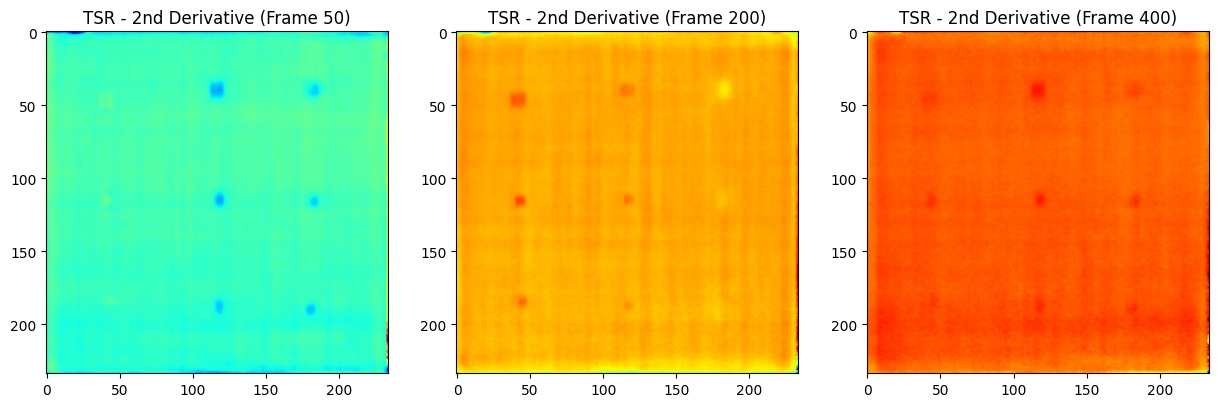

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(tsr_d2[50], cmap='jet')
axes[0].set_title("TSR - 2nd Derivative (Frame 50)")
axes[1].imshow(tsr_d2[200], cmap='jet')
axes[1].set_title("TSR - 2nd Derivative (Frame 200)")
axes[2].imshow(tsr_d2[400], cmap='jet')
axes[2].set_title("TSR - 2nd Derivative (Frame 400)")
plt.show()